# Track training (local)

Reads the JSONL metrics sidecars that `train_pipeline/train_head.py` writes next to its `--output` (e.g. `trained_heads/mlp_sum/model.metrics.jsonl`) and plots per-trait train/val curves — no wandb cloud connection needed.

Set `MODEL_PATHS` (the runs to compare) and `TRAITS` (the traits to plot) in the next cell. Each trait gets its own row of (MSE, PCC) panels; within a panel every run is a distinct color, with **train dashed** and **val a bold solid line in the same color**.

Each JSONL line is one logged row: `train/*` rows on a step cadence, `val/*` rows once per epoch. Run the **live follow** cell to watch runs as they train.

In [ ]:
import json
import time
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import clear_output

# List the runs you want to compare (paths relative to repo root). Each is a
# JSONL metrics sidecar written next to a train_head.py --output.
import os
# MODEL_PATHS = []
# base_dir = "../trained_heads/sweep"
# MODEL_PATHS += [f"{base_dir}/{s}/model.metrics.jsonl" for s in os.listdir(base_dir)]
# sweep_dir = "../trained_heads/sweep_refdelta"
# MODEL_PATHS += [f"{base_dir}/{s}/model.metrics.jsonl" for s in os.listdir(sweep_dir)]

MODEL_PATHS = [
    Path("../trained_heads/sweep/mlp_hw500/model.metrics.jsonl"),
    Path("../trained_heads/sweep/mlp_hw500_snponly/model.metrics.jsonl"),
    Path("../trained_heads/sweep_refdelta/mlp_hw500/model.metrics.jsonl"),
    Path("../trained_heads/sweep_refdelta/mlp_hw500_snponly/model.metrics.jsonl"),
]

print(MODEL_PATHS)

# Traits to plot, one row of (MSE, PCC) panels each.
EVAL_TRAITS = [
    "Alkali spreading value",
    "Amylose content",
    "Panicle number per plant",
    "Protein content",
    "Seed length",
    "Seed number per panicle",
]

def load_metrics(path):
    """Read the JSONL sidecar into a DataFrame, tolerating a half-written
    final line (the trainer may be mid-flush when we read)."""
    rows = []
    with open(path) as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            try:
                rows.append(json.loads(line))
            except json.JSONDecodeError:
                continue  # partial last line during a live write
    return pd.DataFrame(rows)


def load_all(model_paths):
    """Load every run into a {label: DataFrame} dict, labelled by run dir."""
    out = {}
    for p in model_paths:
        p = Path(p)
        label = p.parent.name
        if label in out:  # disambiguate runs sharing a dir
            label = f"{p.parent.name}/{p.stem}"
        out[label] = load_metrics(p)
    return out

def plot_metric(metrics_by_model, metric):
    """One line per run."""
    fig, ax = plt.subplots(figsize=(12, 6))
    cmap = plt.get_cmap("tab10")
    colors = {name: cmap(i % 10) for i, name in enumerate(metrics_by_model)}
    for name, df in metrics_by_model.items():
        color = colors[name]
        ls, lw, alpha = "--", 1.5, 0.7
        col = f"{metric}"
        if col not in df.columns:
            continue
        sub = df.dropna(subset=[col, "step"])
        if len(sub):
            ax.plot(sub["step"], sub[col], linestyle=ls,
                    linewidth=lw, alpha=alpha, color=color,
                    label=f"{name}")
    ax.set(xlabel="step", ylabel=metric)
    ax.legend(fontsize=8)
    fig.tight_layout()
    plt.show()

def plot_traits(metrics_by_model, traits):
    """One row of (MSE, PCC) panels per trait. Each run gets its own color;
    train is dashed, val is a bold solid line in the same color."""
    n = len(traits)
    fig, axes = plt.subplots(n, 2, figsize=(12, 4 * n), squeeze=False)
    cmap = plt.get_cmap("tab10")
    colors = {name: cmap(i % 10) for i, name in enumerate(metrics_by_model)}
    for row, trait in enumerate(traits):
        for ax, metric in [(axes[row][0], "mse"), (axes[row][1], "pcc")]:
            for name, df in metrics_by_model.items():
                color = colors[name]
                for split, ls, lw, alpha in [
                    ("train", "--", 1.5, 0.7),
                    ("val", "-", 2.5, 1.0),
                ]:
                    col = f"{split}/{metric}/{trait}"
                    if col not in df.columns:
                        continue
                    sub = df.dropna(subset=[col, "step"])
                    if len(sub):
                        ax.plot(sub["step"], sub[col], linestyle=ls,
                                linewidth=lw, alpha=alpha, color=color,
                                label=f"{name} {split}")
            ax.set(xlabel="step", ylabel=metric, title=f"{trait} — {metric}")
            ax.legend(fontsize=8)
    fig.tight_layout()
    plt.show()

[PosixPath('../trained_heads/sweep/mlp_hw500/model.metrics.jsonl'), PosixPath('../trained_heads/sweep/mlp_hw500_snponly/model.metrics.jsonl'), PosixPath('../trained_heads/sweep_refdelta/mlp_hw500/model.metrics.jsonl'), PosixPath('../trained_heads/sweep_refdelta/mlp_hw500_snponly/model.metrics.jsonl')]


## Static snapshot
Load and plot whatever has been logged so far.

In [11]:
metrics_by_model = load_all(MODEL_PATHS)

# Latest logged val PCC per model x trait.
summary = pd.DataFrame({
    name: {
        trait: df[f"val/pcc/{trait}"].dropna().iloc[-1]
        for trait in EVAL_TRAITS
        if f"val/pcc/{trait}" in df.columns and df[f"val/pcc/{trait}"].notna().any()
    }
    for name, df in metrics_by_model.items()
})
print("latest val PCC")
print(summary)

latest val PCC
                          mlp_hw500  mlp_hw500_snponly  \
Alkali spreading value     0.519289           0.439249   
Amylose content            0.849023           0.821449   
Panicle number per plant   0.748372           0.746532   
Protein content            0.526009           0.537739   
Seed length                0.589374           0.570681   
Seed number per panicle    0.331849           0.373904   

                          mlp_hw500/model.metrics  \
Alkali spreading value                   0.525170   
Amylose content                          0.848035   
Panicle number per plant                 0.745776   
Protein content                          0.529473   
Seed length                              0.607715   
Seed number per panicle                  0.327427   

                          mlp_hw500_snponly/model.metrics  
Alkali spreading value                           0.438984  
Amylose content                                  0.821481  
Panicle number per plant  

mlp_hw500: 125 rows · steps 0-500
mlp_hw500_snponly: 125 rows · steps 0-500
mlp_hw500/model.metrics: 125 rows · steps 0-500
mlp_hw500_snponly/model.metrics: 125 rows · steps 0-500


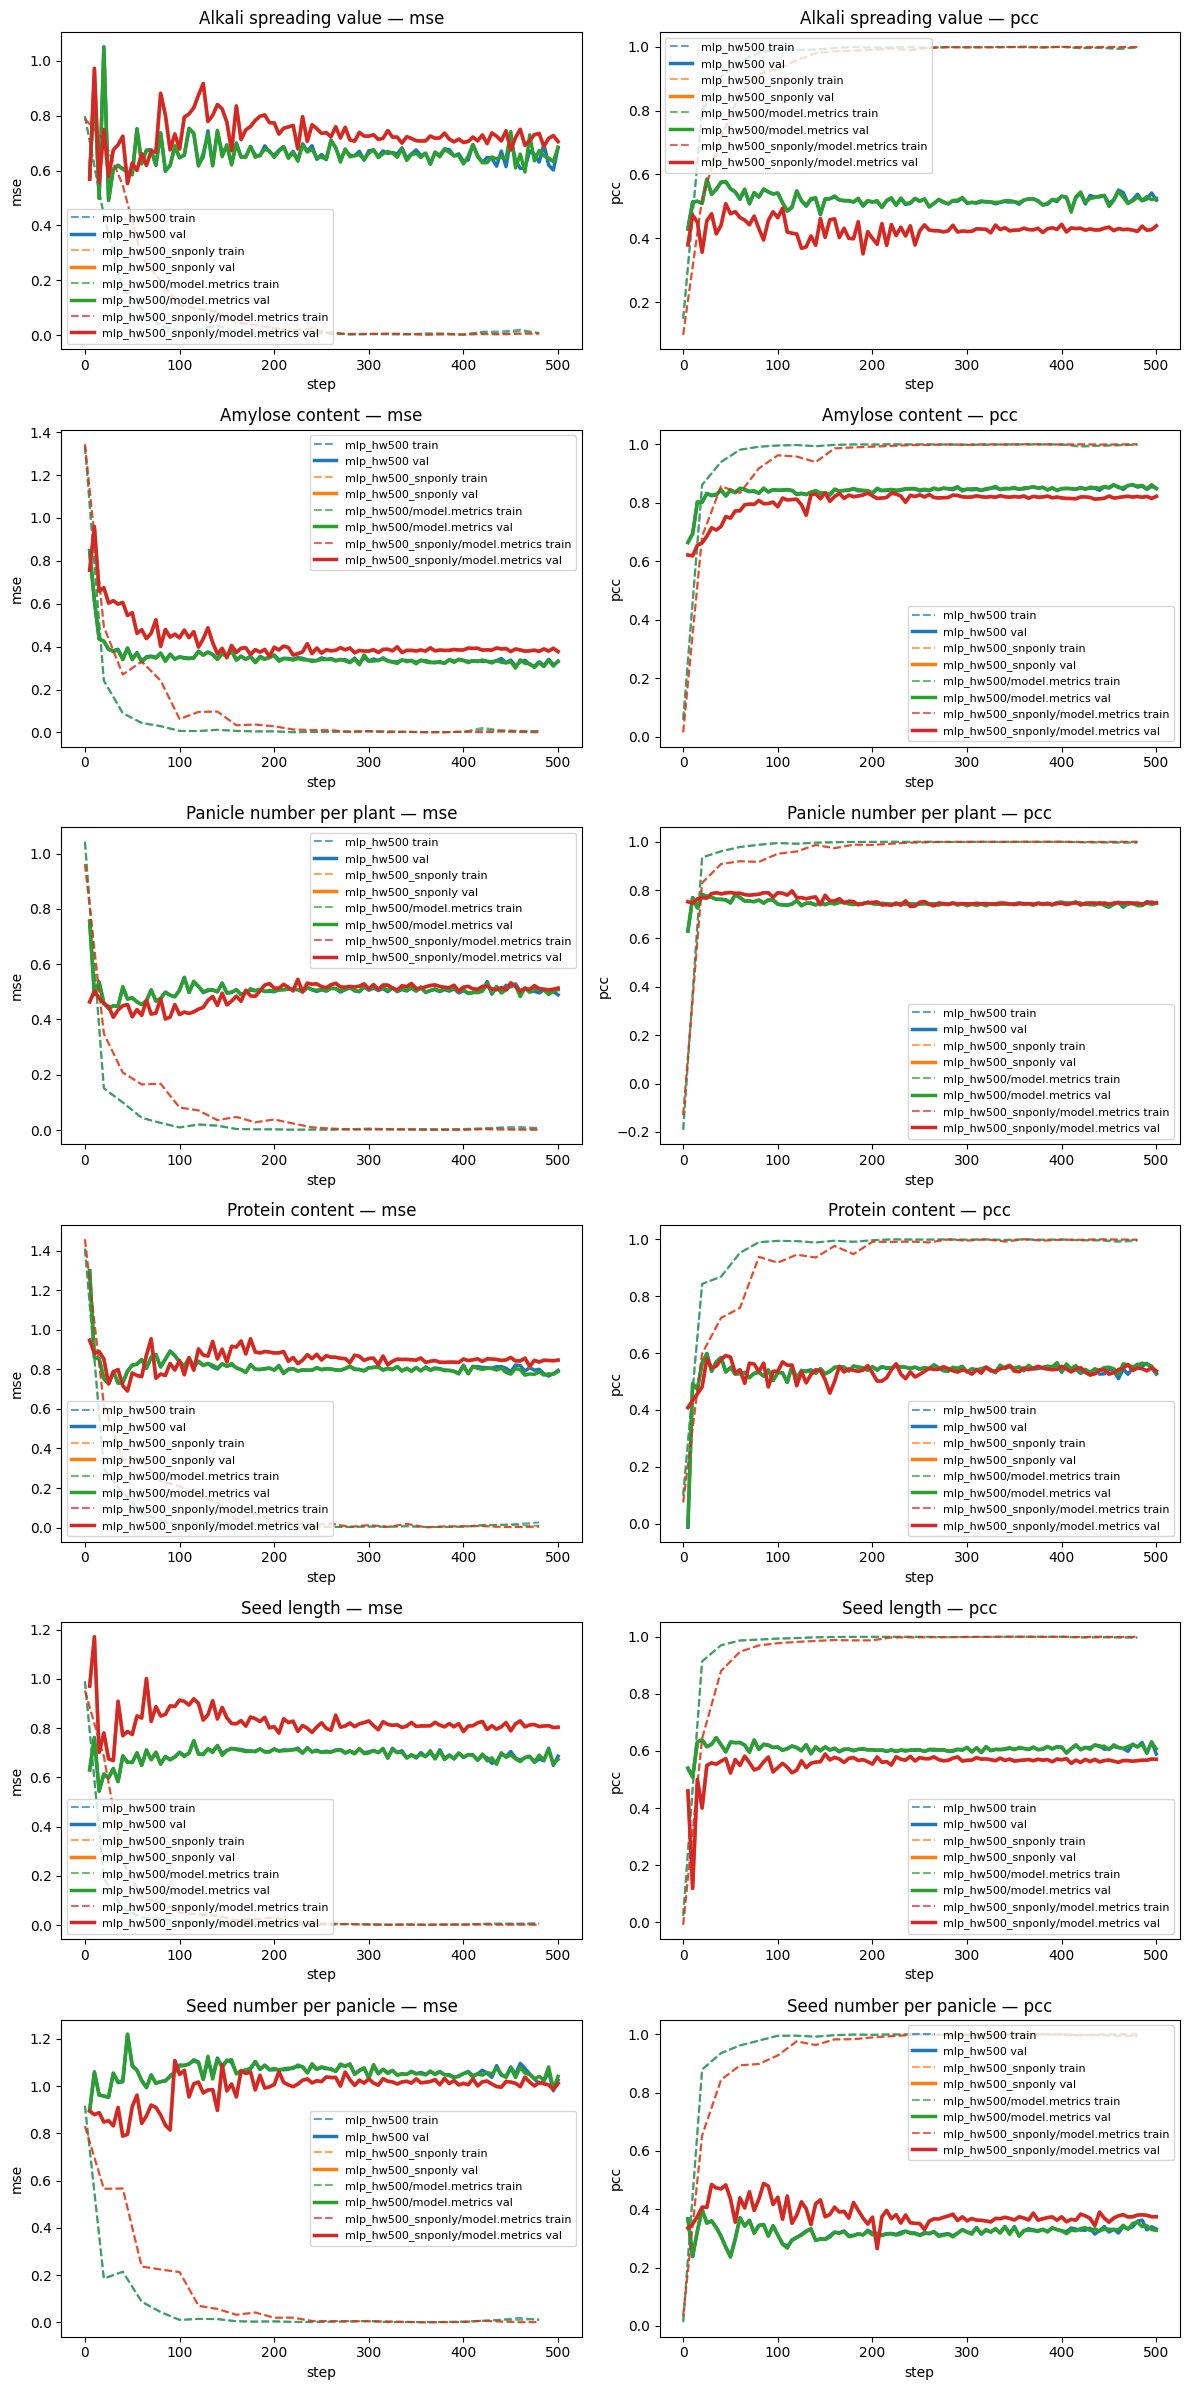

In [12]:
for name, df in metrics_by_model.items():
    print(f"{name}: {len(df)} rows · steps {df['step'].min()}-{df['step'].max()}")
plot_traits(metrics_by_model, EVAL_TRAITS)

## Live follow
Re-reads the file and redraws every few seconds. Interrupt the kernel (■ / `Ctrl-C`) to stop.

In [ ]:
REFRESH_SEC = 5

try:
    while True:
        metrics_by_model = load_all(MODEL_PATHS)
        clear_output(wait=True)
        plot_traits(metrics_by_model, TRAITS)
        last = max((int(df["step"].max()) for df in metrics_by_model.values() if len(df)), default=None)
        print(f"{len(metrics_by_model)} runs · last step {last} · refreshing every {REFRESH_SEC}s (interrupt to stop)")
        time.sleep(REFRESH_SEC)
except KeyboardInterrupt:
    print("stopped following")